# Red Neuronal con CIFAR-10 - Comparación RGB vs Escala de Grises

Este cuaderno implementa y compara dos arquitecturas de redes neuronales para clasificar imágenes del dataset CIFAR-10:
1. **Red Neuronal con imágenes RGB** (color original)
2. **Red Neuronal con imágenes en escala de grises**

## Dataset CIFAR-10
- 60,000 imágenes en color de 32x32 píxeles (RGB)
- 10 clases de objetos:
  - 0: Airplane (Avión)
  - 1: Automobile (Automóvil)
  - 2: Bird (Pájaro)
  - 3: Cat (Gato)
  - 4: Deer (Ciervo)
  - 5: Dog (Perro)
  - 6: Frog (Rana)
  - 7: Horse (Caballo)
  - 8: Ship (Barco)
  - 9: Truck (Camión)

Cargando dataset CIFAR-10...

Forma de los datos de entrenamiento: (50000, 32, 32, 3)
Forma de los datos de test: (10000, 32, 32, 3)
Forma de las etiquetas de entrenamiento: (50000,)
Forma de las etiquetas de test: (10000,)

Rango de valores de píxeles: [0, 255]
Número de clases: 10
Dimensiones de cada imagen: 32x32 píxeles, 3 canales (RGB)

Distribución de clases en el conjunto de entrenamiento:
  0 (Airplane): 5000 imágenes (10.00%)
  1 (Automobile): 5000 imágenes (10.00%)
  2 (Bird): 5000 imágenes (10.00%)
  3 (Cat): 5000 imágenes (10.00%)
  4 (Deer): 5000 imágenes (10.00%)
  5 (Dog): 5000 imágenes (10.00%)
  6 (Frog): 5000 imágenes (10.00%)
  7 (Horse): 5000 imágenes (10.00%)
  8 (Ship): 5000 imágenes (10.00%)
  9 (Truck): 5000 imágenes (10.00%)


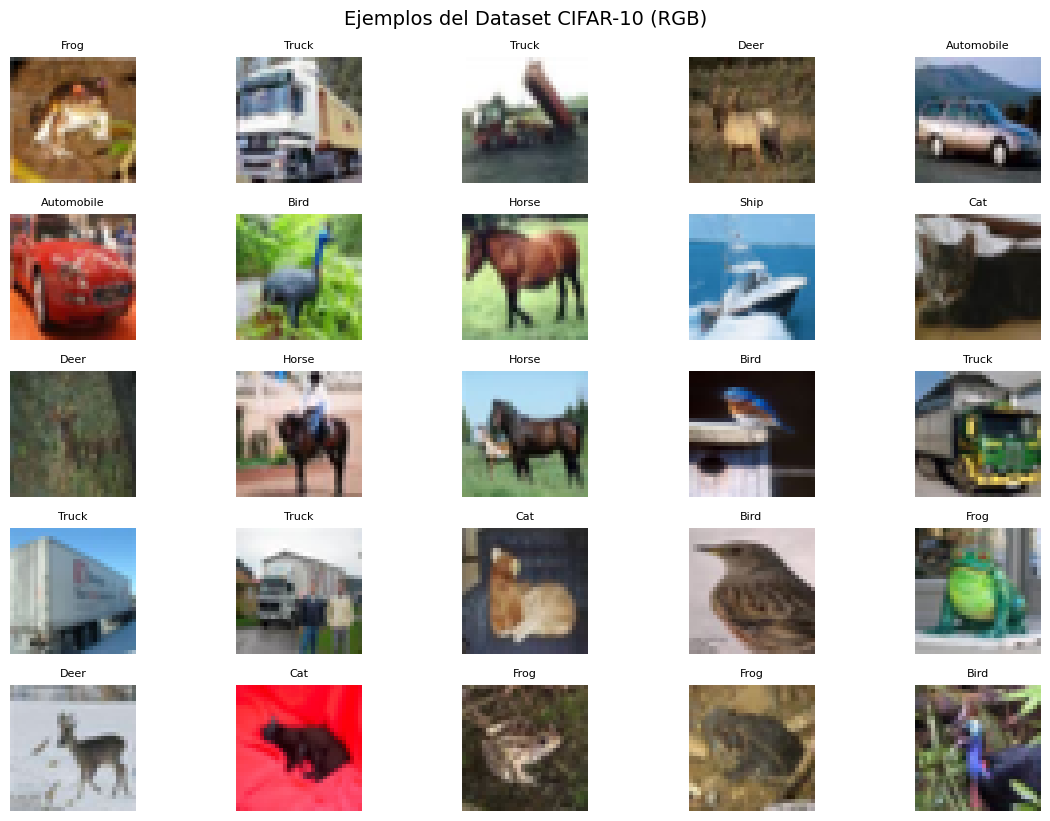


INFORMACIÓN DEL DATASET
Total de imágenes de entrenamiento: 50000
Total de imágenes de test: 10000
Dimensiones de cada imagen: 32x32 píxeles con 3 canales RGB
Total de características por imagen (RGB): 3072 píxeles
Número de clases: 10

NOTA: CIFAR-10 es un dataset de clasificación multiclase con 10 categorías.
Las imágenes están en color RGB (0-255 por canal).


In [15]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Configuración
np.random.seed(42)
tf.random.set_seed(42)

# Cargar el dataset CIFAR-10
print("Cargando dataset CIFAR-10...")
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Nombres de las clases
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Aplanar las etiquetas (vienen como arrays de forma (n, 1))
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

# Convertir etiquetas a one-hot encoding para el modelo
y_train_cat = keras.utils.to_categorical(y_train_full, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print(f"\nForma de los datos de entrenamiento: {X_train_full.shape}")
print(f"Forma de los datos de test: {X_test.shape}")
print(f"Forma de las etiquetas de entrenamiento: {y_train_full.shape}")
print(f"Forma de las etiquetas de test: {y_test.shape}")

print(f"\nRango de valores de píxeles: [{X_train_full.min()}, {X_train_full.max()}]")
print(f"Número de clases: {len(class_names)}")
print(f"Dimensiones de cada imagen: 32x32 píxeles, 3 canales (RGB)")

# Mostrar distribución de clases
print("\nDistribución de clases en el conjunto de entrenamiento:")
unique, counts = np.unique(y_train_full, return_counts=True)
for i, (clase, count) in enumerate(zip(unique, counts)):
    print(f"  {clase} ({class_names[clase]}): {count} imágenes ({count/len(y_train_full)*100:.2f}%)")

# Visualizar algunas imágenes de ejemplo
plt.figure(figsize=(12, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train_full[i])
    plt.title(class_names[y_train_full[i]], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Ejemplos del Dataset CIFAR-10 (RGB)', y=1.02, fontsize=14)
plt.show()

print("\n" + "="*80)
print("INFORMACIÓN DEL DATASET")
print("="*80)
print(f"Total de imágenes de entrenamiento: {len(X_train_full)}")
print(f"Total de imágenes de test: {len(X_test)}")
print(f"Dimensiones de cada imagen: 32x32 píxeles con 3 canales RGB")
print(f"Total de características por imagen (RGB): {32*32*3} píxeles")
print(f"Número de clases: {len(class_names)}")
print("\nNOTA: CIFAR-10 es un dataset de clasificación multiclase con 10 categorías.")
print("Las imágenes están en color RGB (0-255 por canal).")

## Primera Red Neuronal - Imágenes RGB (Color)

In [16]:
# Red Neuronal para imágenes RGB
print("="*80)
print("RED NEURONAL #1 - CLASIFICACIÓN CON IMÁGENES RGB")
print("="*80)
print("Configuración: Entrada de imágenes 32x32x3 (RGB)")
print("Arquitectura: CNN con 2 bloques Conv2D (32 y 64 filtros) + BatchNorm + MaxPool + Dropout")
print("="*80 + "\n")

split_index = int(len(X_train_full) * 0.8)
X_train_rgb = X_train_full[:split_index]
X_val_rgb = X_train_full[split_index:]
y_train_rgb = y_train_cat[:split_index]
y_val_rgb = y_train_cat[split_index:]

X_train_rgb = X_train_rgb / 255.0
X_val_rgb = X_val_rgb / 255.0
X_test_rgb = X_test / 255.0

print(f"Forma de X_train_rgb: {X_train_rgb.shape}")
print(f"Forma de X_val_rgb: {X_val_rgb.shape}")
print(f"Forma de X_test_rgb: {X_test_rgb.shape}")

model_rgb = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3), name='conv1'),
    BatchNormalization(name='bn1'),
    MaxPooling2D((2, 2), name='pool1'),
    Dropout(0.25, name='dropout1'),

    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    BatchNormalization(name='bn2'),
    MaxPooling2D((2, 2), name='pool2'),
    Dropout(0.25, name='dropout2'),

    Flatten(name='flatten'),
    Dense(128, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout3'),
    Dense(10, activation='softmax', name='output')
])

model_rgb.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\nResumen del modelo RGB:")
model_rgb.summary()

# Entrenamiento con early stopping
early_stop_rgb = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo RGB...")
history_rgb = model_rgb.fit(X_train_rgb, y_train_rgb,
                            epochs=100,
                            batch_size=128,
                            validation_data=(X_val_rgb, y_val_rgb),
                            callbacks=[early_stop_rgb],
                            verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test (RGB) ---")
test_loss_rgb, test_accuracy_rgb = model_rgb.evaluate(X_test_rgb, y_test_cat, verbose=0)
print(f"Pérdida en test: {test_loss_rgb:.4f}")
print(f"Precisión en test: {test_accuracy_rgb:.4f}")

# Predicciones
y_pred_rgb = model_rgb.predict(X_test_rgb, verbose=0)
y_pred_classes_rgb = np.argmax(y_pred_rgb, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas (RGB) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_classes_rgb):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0):.4f}")

# Reporte de clasificación
print("\n--- Reporte de Clasificación (RGB) ---")
print(f"F1-Score (macro): {f1_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0):.4f}")
print(classification_report(y_test, y_pred_classes_rgb, target_names=class_names, zero_division=0))

RED NEURONAL #1 - CLASIFICACIÓN CON IMÁGENES RGB
Configuración: Entrada de imágenes 32x32x3 (RGB)
Arquitectura: CNN con 2 bloques Conv2D (32 y 64 filtros) + BatchNorm + MaxPool + Dropout

Forma de X_train_rgb: (40000, 32, 32, 3)
Forma de X_val_rgb: (10000, 32, 32, 3)
Forma de X_test_rgb: (10000, 32, 32, 3)

Resumen del modelo RGB:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,482 (2.08 MB)

 Trainable params: 545,290 (2.08 MB)

 Non-trainable params: 192 (768.00 B)


Entrenando modelo RGB...
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - accuracy: 0.2177 - loss: 2.2845 - val_accuracy: 0.1456 - val_loss: 7.3272
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3867 - loss: 1.6653 - val_accuracy: 0.4720 - val_loss: 1.5540
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4590 - loss: 1.4853 - val_accuracy: 0.4555 - val_loss: 1.6843
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5016 - loss: 1.3641 - val_accuracy: 0.6100 - val_loss: 1.1352
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5358 - loss: 1.2932 - val_accuracy: 0.6197 - val_loss: 1.0929
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5608 - loss: 1.2244 - val_accuracy: 0.6138 - val_loss: 1.1626
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5814 - loss: 1.1782 - val_accuracy: 0.6300 - val_loss: 1.0924
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.60

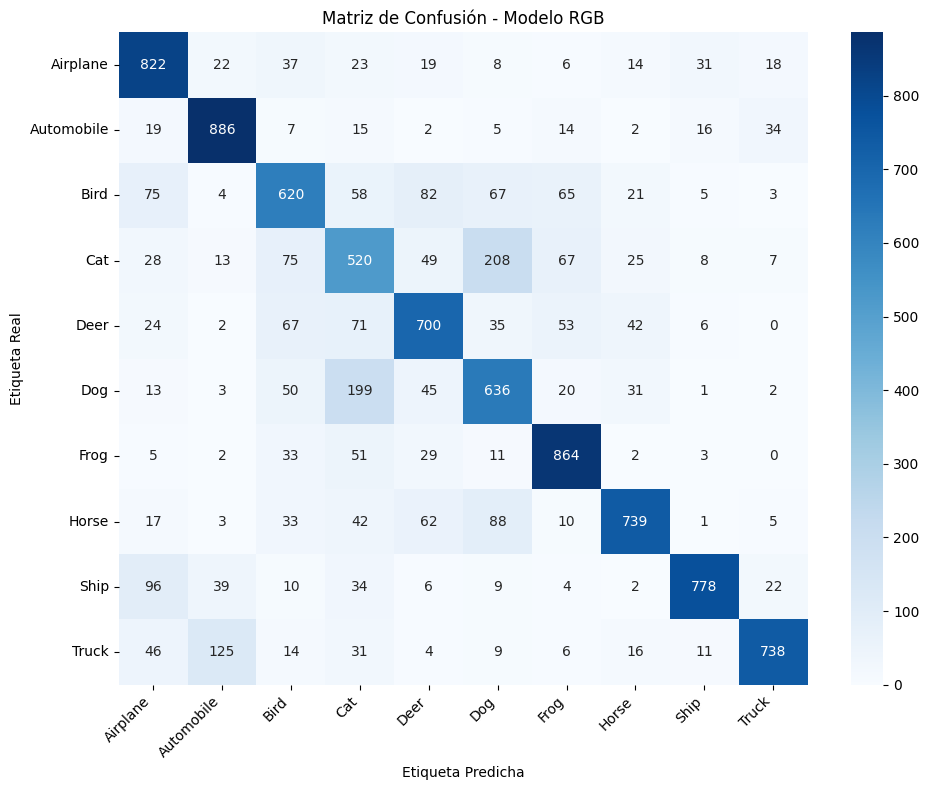

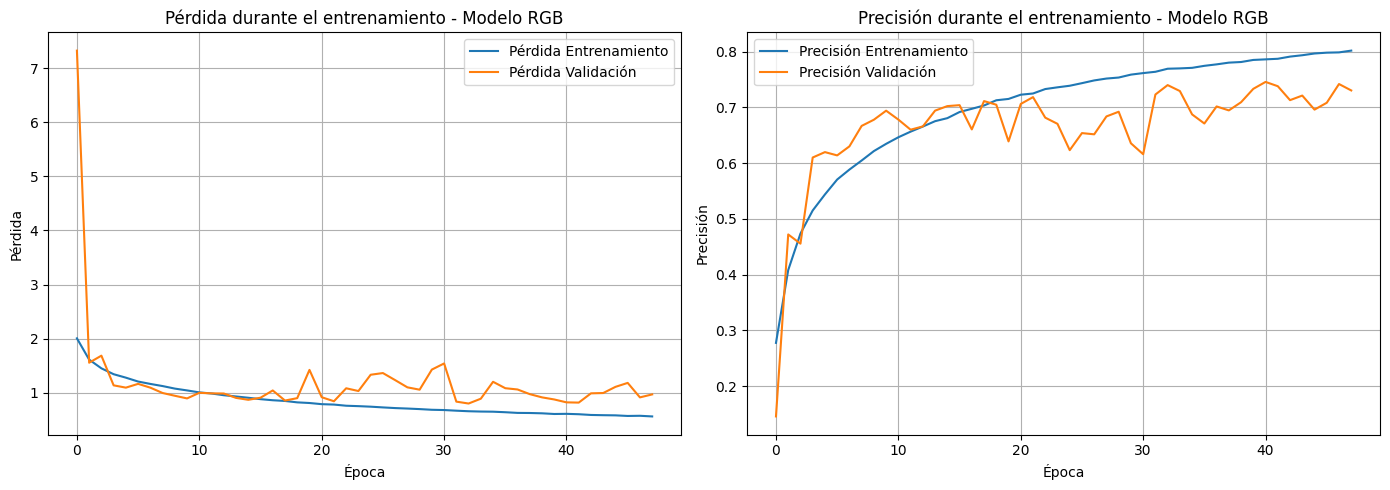


Modelo RGB entrenado exitosamente.


In [17]:
# Visualización de resultados del modelo RGB
# Matriz de confusión
cm_rgb = confusion_matrix(y_test, y_pred_classes_rgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo RGB')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_rgb.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_rgb.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo RGB')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_rgb.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_rgb.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo RGB')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nModelo RGB entrenado exitosamente.")

VISUALIZACIÓN DE PREDICCIONES - MODELO RGB



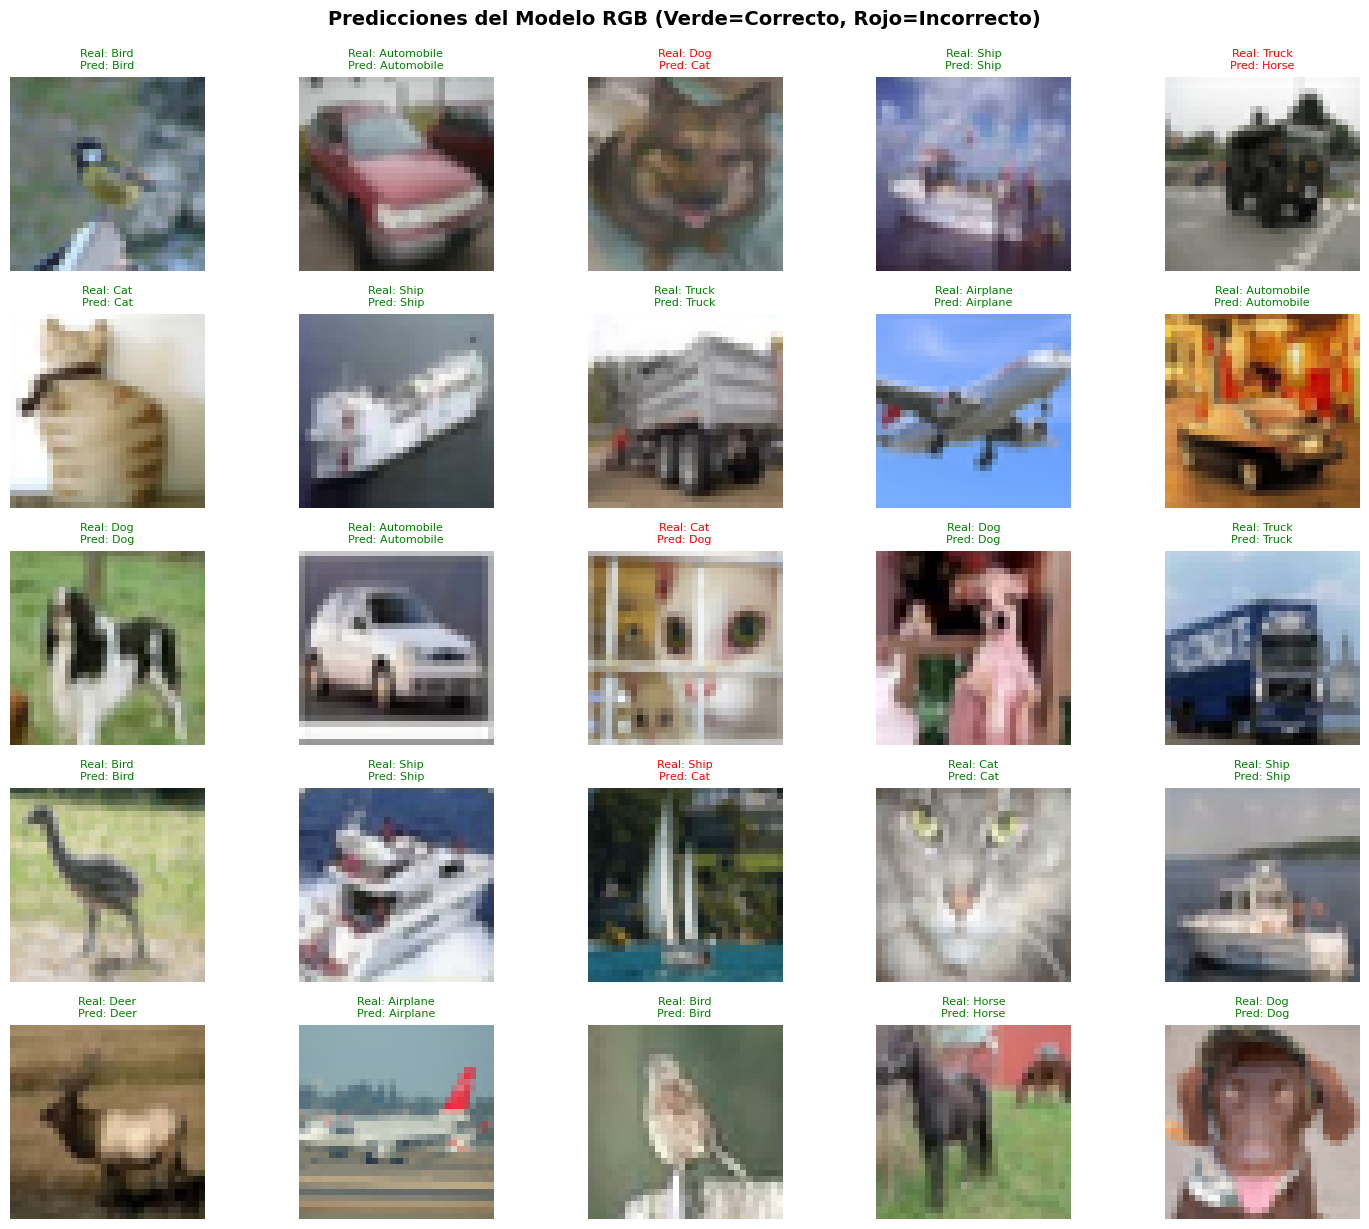


Predicciones correctas: 7303 de 10000 (73.03%)
Predicciones incorrectas: 2697 de 10000 (26.97%)


In [18]:
# Visualización de predicciones del modelo RGB
print("="*80)
print("VISUALIZACIÓN DE PREDICCIONES - MODELO RGB")
print("="*80 + "\n")

# Seleccionar algunas imágenes de prueba aleatoriamente
np.random.seed(42)
indices_aleatorios = np.random.choice(len(X_test), 25, replace=False)

# Visualizar las predicciones
plt.figure(figsize=(15, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test[indices_aleatorios[i]])

    # Color verde si es correcto, rojo si es incorrecto
    color = 'green' if y_pred_classes_rgb[indices_aleatorios[i]] == y_test[indices_aleatorios[i]] else 'red'

    plt.title(f'Real: {class_names[y_test[indices_aleatorios[i]]]}\n'
              f'Pred: {class_names[y_pred_classes_rgb[indices_aleatorios[i]]]}',
              fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Predicciones del Modelo RGB (Verde=Correcto, Rojo=Incorrecto)',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Estadísticas de predicción
correctas_rgb = np.sum(y_pred_classes_rgb == y_test)
incorrectas_rgb = len(y_test) - correctas_rgb
print(f"\nPredicciones correctas: {correctas_rgb} de {len(y_test)} ({correctas_rgb/len(y_test)*100:.2f}%)")
print(f"Predicciones incorrectas: {incorrectas_rgb} de {len(y_test)} ({incorrectas_rgb/len(y_test)*100:.2f}%)")

## Segunda Red Neuronal - Imágenes en Escala de Grises

CONVERSIÓN DE IMÁGENES A ESCALA DE GRISES

Convirtiendo imágenes a escala de grises...

Forma de X_train_gray: (40000, 32, 32, 1)
Forma de X_val_gray: (10000, 32, 32, 1)
Forma de X_test_gray: (10000, 32, 32, 1)

Conversión completada exitosamente.


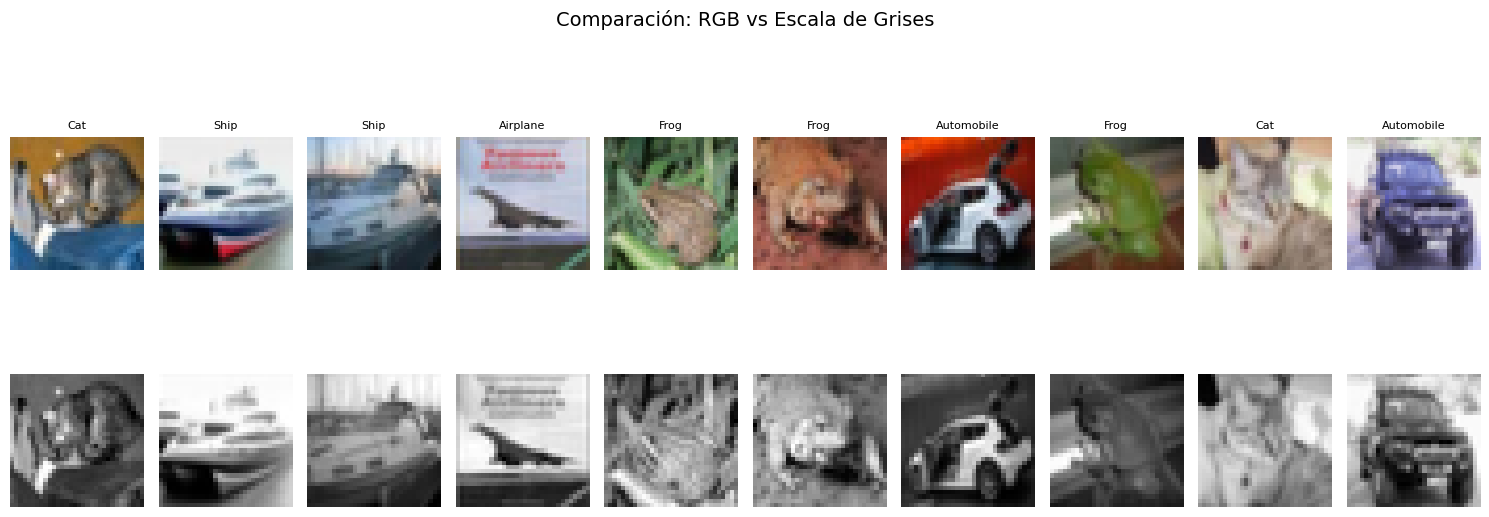

In [19]:
# Convertir imágenes RGB a escala de grises
print("="*80)
print("CONVERSIÓN DE IMÁGENES A ESCALA DE GRISES")
print("="*80 + "\n")

def rgb_a_grises(imagenes_rgb):
    """
    Convierte imágenes RGB a escala de grises usando la fórmula estándar.
    Formula: 0.299*R + 0.587*G + 0.114*B
    """
    return np.dot(imagenes_rgb[...,:3], [0.299, 0.587, 0.114])

# Convertir datasets a escala de grises
print("Convirtiendo imágenes a escala de grises...")
X_train_gray_full = rgb_a_grises(X_train_full)
X_test_gray = rgb_a_grises(X_test)

# Dividir en entrenamiento y validación
X_train_gray = X_train_gray_full[:split_index]
X_val_gray = X_train_gray_full[split_index:]

# Normalizar
X_train_gray = X_train_gray / 255.0
X_val_gray = X_val_gray / 255.0
X_test_gray = X_test_gray / 255.0

X_train_gray = np.expand_dims(X_train_gray, axis=-1)
X_val_gray = np.expand_dims(X_val_gray, axis=-1)
X_test_gray = np.expand_dims(X_test_gray, axis=-1)

print(f"\nForma de X_train_gray: {X_train_gray.shape}")
print(f"Forma de X_val_gray: {X_val_gray.shape}")
print(f"Forma de X_test_gray: {X_test_gray.shape}")

# Visualizar la diferencia entre RGB y escala de grises
plt.figure(figsize=(15, 6))
for i in range(10):
    # RGB
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i])
    if i == 0:
        plt.ylabel('RGB', fontsize=12, rotation=0, ha='right', va='center')
    plt.title(class_names[y_test[i]], fontsize=8)
    plt.axis('off')

    # Escala de grises
    plt.subplot(2, 10, i + 11)
    plt.imshow(X_test_gray[i], cmap='gray')
    if i == 0:
        plt.ylabel('Grises', fontsize=12, rotation=0, ha='right', va='center')
    plt.axis('off')

plt.tight_layout()

plt.suptitle('Comparación: RGB vs Escala de Grises', y=1.02, fontsize=14)
print("\nConversión completada exitosamente.")

plt.show()

In [20]:
# Red Neuronal para imágenes en escala de grises
print("="*80)
print("RED NEURONAL #2 - CLASIFICACIÓN CON IMÁGENES EN ESCALA DE GRISES")
print("="*80)
print("Configuración: Entrada de imágenes 32x32x1 (escala de grises)")
print("Arquitectura: CNN con 2 bloques Conv2D (32 y 64 filtros) + BatchNorm + MaxPool + Dropout")
print("="*80 + "\n")

model_gray = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 1), name='conv1'),
    BatchNormalization(name='bn1'),
    MaxPooling2D((2, 2), name='pool1'),
    Dropout(0.25, name='dropout1'),

    Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'),
    BatchNormalization(name='bn2'),
    MaxPooling2D((2, 2), name='pool2'),
    Dropout(0.25, name='dropout2'),

    Flatten(name='flatten'),
    Dense(128, activation='relu', name='dense1'),
    Dropout(0.5, name='dropout3'),
    Dense(10, activation='softmax', name='output')
])

model_gray.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

print("\nResumen del modelo en escala de grises:")
model_gray.summary()

# Entrenamiento con early stopping
early_stop_gray = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

print("\nEntrenando modelo en escala de grises...")
history_gray = model_gray.fit(X_train_gray, y_train_rgb,
                              epochs=100,
                              batch_size=128,
                              validation_data=(X_val_gray, y_val_rgb),
                              callbacks=[early_stop_gray],
                              verbose=1)

# Evaluación
print("\n--- Evaluación en conjunto de test (Escala de Grises) ---")
test_loss_gray, test_accuracy_gray = model_gray.evaluate(X_test_gray, y_test_cat, verbose=0)
print(f"Pérdida en test: {test_loss_gray:.4f}")
print(f"Precisión en test: {test_accuracy_gray:.4f}")

# Predicciones
y_pred_gray = model_gray.predict(X_test_gray, verbose=0)
y_pred_classes_gray = np.argmax(y_pred_gray, axis=1)

# Métricas detalladas
print("\n--- Métricas Detalladas (Escala de Grises) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_classes_gray):.4f}")

print(f"Precision (macro): {precision_score(y_test, y_pred_classes_gray, average='macro', zero_division=0):.4f}")
print(classification_report(y_test, y_pred_classes_gray, target_names=class_names, zero_division=0))

print(f"Recall (macro): {recall_score(y_test, y_pred_classes_gray, average='macro', zero_division=0):.4f}")
print("\n--- Reporte de Clasificación (Escala de Grises) ---")

print(f"F1-Score (macro): {f1_score(y_test, y_pred_classes_gray, average='macro', zero_division=0):.4f}")# Reporte de clasificación


RED NEURONAL #2 - CLASIFICACIÓN CON IMÁGENES EN ESCALA DE GRISES
Configuración: Entrada de imágenes 32x32x1 (escala de grises)
Arquitectura: CNN con 2 bloques Conv2D (32 y 64 filtros) + BatchNorm + MaxPool + Dropout


Resumen del modelo en escala de grises:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 544,906 (2.08 MB)

 Trainable params: 544,714 (2.08 MB)

 Non-trainable params: 192 (768.00 B)


Entrenando modelo en escala de grises...
Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.1892 - loss: 2.3370 - val_accuracy: 0.1826 - val_loss: 4.5805
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3408 - loss: 1.7926 - val_accuracy: 0.1573 - val_loss: 4.1110
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4066 - loss: 1.6138 - val_accuracy: 0.3384 - val_loss: 2.1138
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4586 - loss: 1.5021 - val_accuracy: 0.4361 - val_loss: 1.7914
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4972 - loss: 1.4085 - val_accuracy: 0.5425 - val_loss: 1.3764
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5253 - loss: 1.3303 - val_accuracy: 0.5710 - val_loss: 1.3326
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5511 - loss: 1.2813 - val_accuracy: 0.5376 - val_loss: 1.5203
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step 

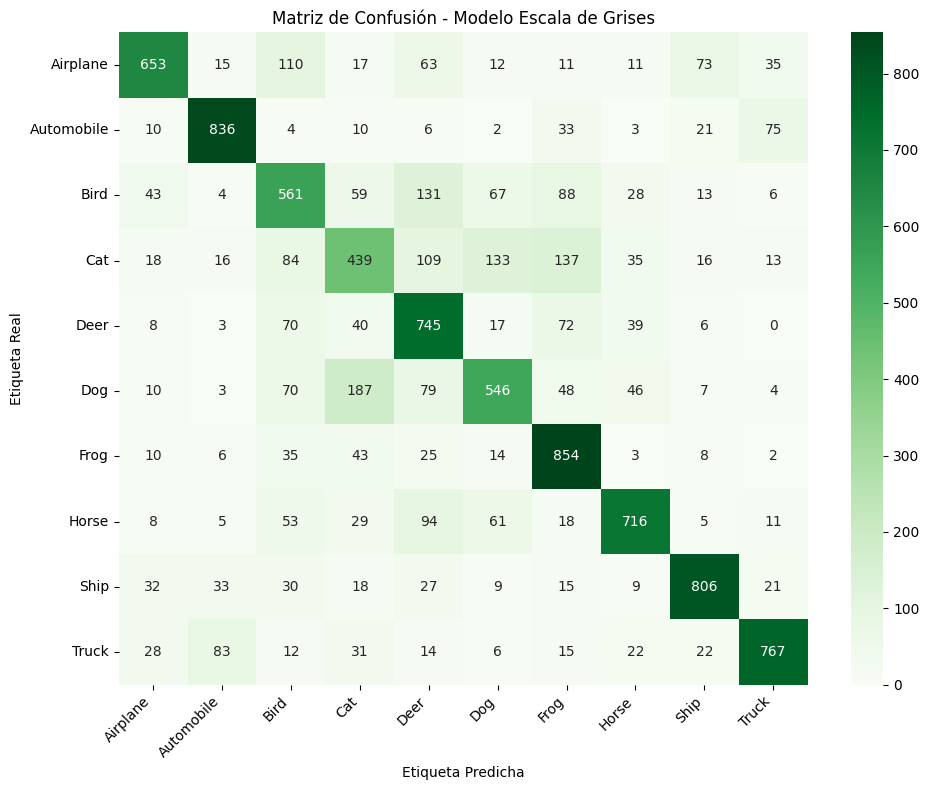

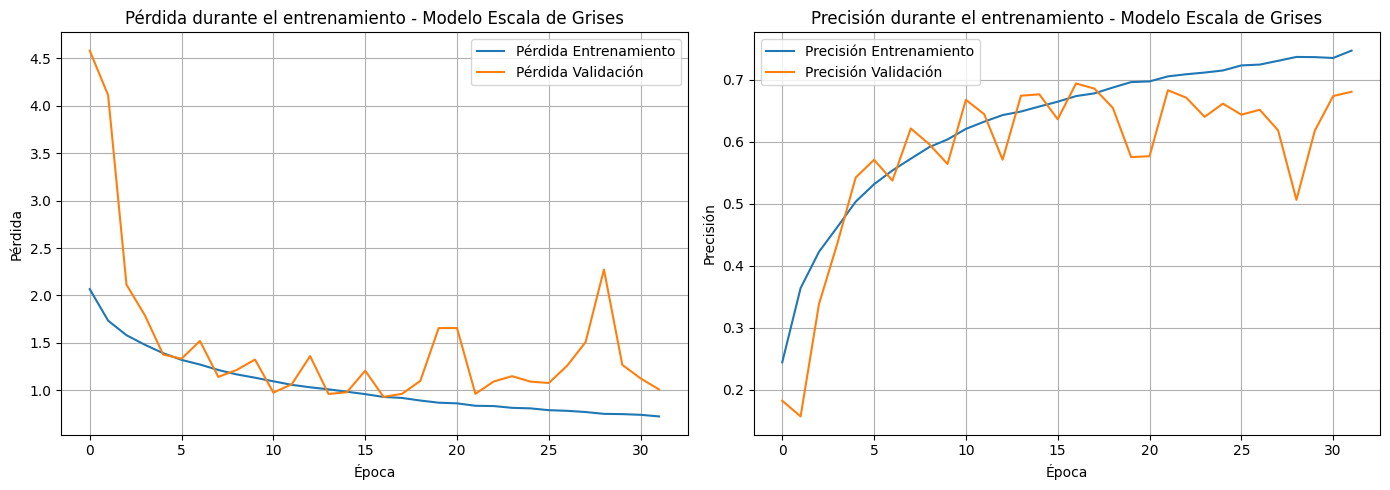


Modelo en escala de grises entrenado exitosamente.


In [21]:
# Visualización de resultados del modelo en escala de grises
# Matriz de confusión
cm_gray = confusion_matrix(y_test, y_pred_classes_gray)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gray, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Modelo Escala de Grises')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Gráfico de pérdida y precisión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_gray.history['loss'], label='Pérdida Entrenamiento')
ax1.plot(history_gray.history['val_loss'], label='Pérdida Validación')
ax1.set_title('Pérdida durante el entrenamiento - Modelo Escala de Grises')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history_gray.history['accuracy'], label='Precisión Entrenamiento')
ax2.plot(history_gray.history['val_accuracy'], label='Precisión Validación')
ax2.set_title('Precisión durante el entrenamiento - Modelo Escala de Grises')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nModelo en escala de grises entrenado exitosamente.")

VISUALIZACIÓN DE PREDICCIONES - MODELO ESCALA DE GRISES



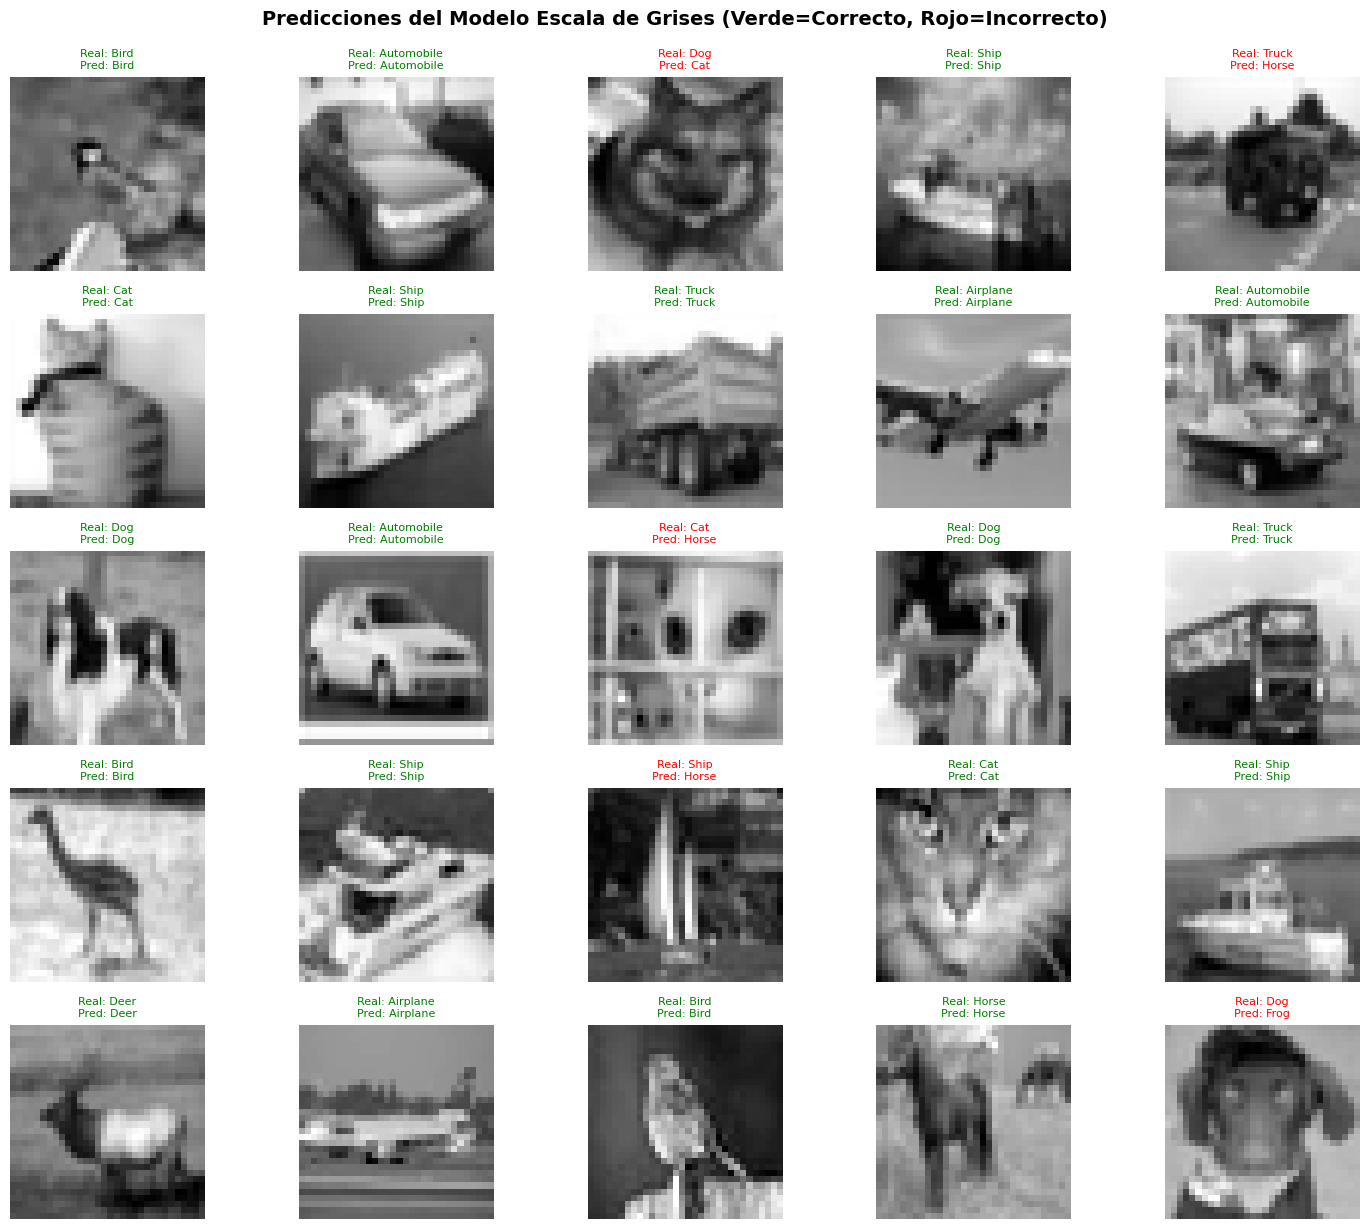


Predicciones correctas: 6923 de 10000 (69.23%)
Predicciones incorrectas: 3077 de 10000 (30.77%)


In [22]:
# Visualización de predicciones del modelo en escala de grises
print("="*80)
print("VISUALIZACIÓN DE PREDICCIONES - MODELO ESCALA DE GRISES")
print("="*80 + "\n")

# Usar los mismos índices aleatorios para comparación justa
plt.figure(figsize=(15, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_test_gray[indices_aleatorios[i]], cmap='gray')

    # Color verde si es correcto, rojo si es incorrecto
    color = 'green' if y_pred_classes_gray[indices_aleatorios[i]] == y_test[indices_aleatorios[i]] else 'red'

    plt.title(f'Real: {class_names[y_test[indices_aleatorios[i]]]}\n'
              f'Pred: {class_names[y_pred_classes_gray[indices_aleatorios[i]]]}',
              fontsize=8, color=color)
    plt.axis('off')

plt.tight_layout()
plt.suptitle('Predicciones del Modelo Escala de Grises (Verde=Correcto, Rojo=Incorrecto)',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Estadísticas de predicción
correctas_gray = np.sum(y_pred_classes_gray == y_test)
incorrectas_gray = len(y_test) - correctas_gray
print(f"\nPredicciones correctas: {correctas_gray} de {len(y_test)} ({correctas_gray/len(y_test)*100:.2f}%)")
print(f"Predicciones incorrectas: {incorrectas_gray} de {len(y_test)} ({incorrectas_gray/len(y_test)*100:.2f}%)")

## Comparación de Modelos RGB vs Escala de Grises

COMPARACIÓN DE MODELOS: RGB vs ESCALA DE GRISES

           Métrica    Modelo RGB  Modelo Escala de Grises  Diferencia
          Accuracy      0.730300                 0.692300    0.038000
 Precision (macro)      0.737063                 0.697577    0.039487
    Recall (macro)      0.730300                 0.692300    0.038000
  F1-Score (macro)      0.731334                 0.691139    0.040194
   Pérdida en test      0.810653                 0.933132   -0.122479
 Épocas entrenadas     48.000000                32.000000   16.000000
Parámetros totales 545482.000000            544906.000000  576.000000


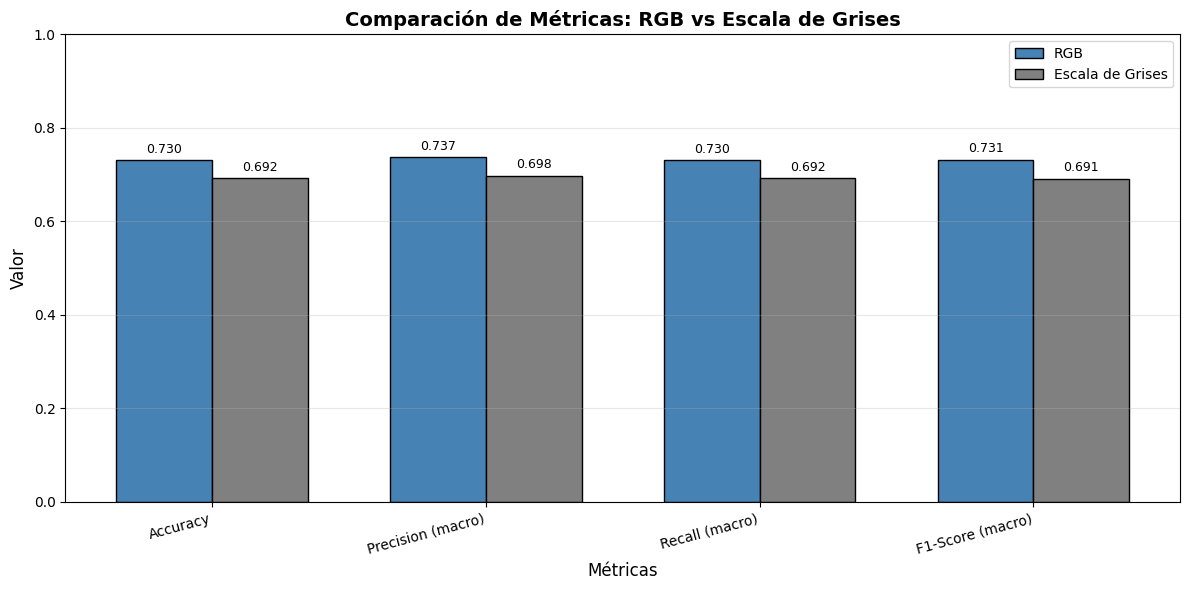


🏆 GANADOR: Modelo RGB
   Ventaja: 3.80% más de accuracy

📊 ANÁLISIS:
   - El modelo RGB tiene 0.1% más parámetros que el modelo en escala de grises
   - Entrada RGB: 32x32x3 = 3,072 características
   - Entrada Grises: 32x32 = 1,024 características
   - Reducción de características: 66.7%


In [23]:
# Comparación detallada de ambos modelos
print("="*80)
print("COMPARACIÓN DE MODELOS: RGB vs ESCALA DE GRISES")
print("="*80 + "\n")

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)',
                'Pérdida en test', 'Épocas entrenadas', 'Parámetros totales'],
    'Modelo RGB': [
        accuracy_score(y_test, y_pred_classes_rgb),
        precision_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0),
        recall_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0),
        f1_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0),
        test_loss_rgb,
        len(history_rgb.history['loss']),
        model_rgb.count_params()
    ],
    'Modelo Escala de Grises': [
        accuracy_score(y_test, y_pred_classes_gray),
        precision_score(y_test, y_pred_classes_gray, average='macro', zero_division=0),
        recall_score(y_test, y_pred_classes_gray, average='macro', zero_division=0),
        f1_score(y_test, y_pred_classes_gray, average='macro', zero_division=0),
        test_loss_gray,
        len(history_gray.history['loss']),
        model_gray.count_params()
    ]
})

# Calcular diferencia
comparacion['Diferencia'] = comparacion['Modelo RGB'] - comparacion['Modelo Escala de Grises']

print(comparacion.to_string(index=False))

# Visualización comparativa de métricas
metricas_comparar = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
valores_rgb = [
    accuracy_score(y_test, y_pred_classes_rgb),
    precision_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0),
    recall_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0),
    f1_score(y_test, y_pred_classes_rgb, average='macro', zero_division=0)
]
valores_gray = [
    accuracy_score(y_test, y_pred_classes_gray),
    precision_score(y_test, y_pred_classes_gray, average='macro', zero_division=0),
    recall_score(y_test, y_pred_classes_gray, average='macro', zero_division=0),
    f1_score(y_test, y_pred_classes_gray, average='macro', zero_division=0)
]

x = np.arange(len(metricas_comparar))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, valores_rgb, width, label='RGB', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, valores_gray, width, label='Escala de Grises', color='gray', edgecolor='black')

ax.set_xlabel('Métricas', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de Métricas: RGB vs Escala de Grises', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_comparar, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Determinar el modelo ganador
print("\n" + "="*80)
if test_accuracy_rgb > test_accuracy_gray:
    diff = (test_accuracy_rgb - test_accuracy_gray) * 100
    print(f"🏆 GANADOR: Modelo RGB")
    print(f"   Ventaja: {diff:.2f}% más de accuracy")
elif test_accuracy_gray > test_accuracy_rgb:
    diff = (test_accuracy_gray - test_accuracy_rgb) * 100
    print(f"🏆 GANADOR: Modelo Escala de Grises")
    print(f"   Ventaja: {diff:.2f}% más de accuracy")
else:
    print(f"🤝 EMPATE: Ambos modelos tienen la misma precisión")

print("\n📊 ANÁLISIS:")
param_diff = ((model_rgb.count_params() - model_gray.count_params()) / model_gray.count_params()) * 100
print(f"   - El modelo RGB tiene {param_diff:.1f}% más parámetros que el modelo en escala de grises")
print(f"   - Entrada RGB: 32x32x3 = 3,072 características")
print(f"   - Entrada Grises: 32x32 = 1,024 características")
print(f"   - Reducción de características: {((3072-1024)/3072)*100:.1f}%")
print("="*80)

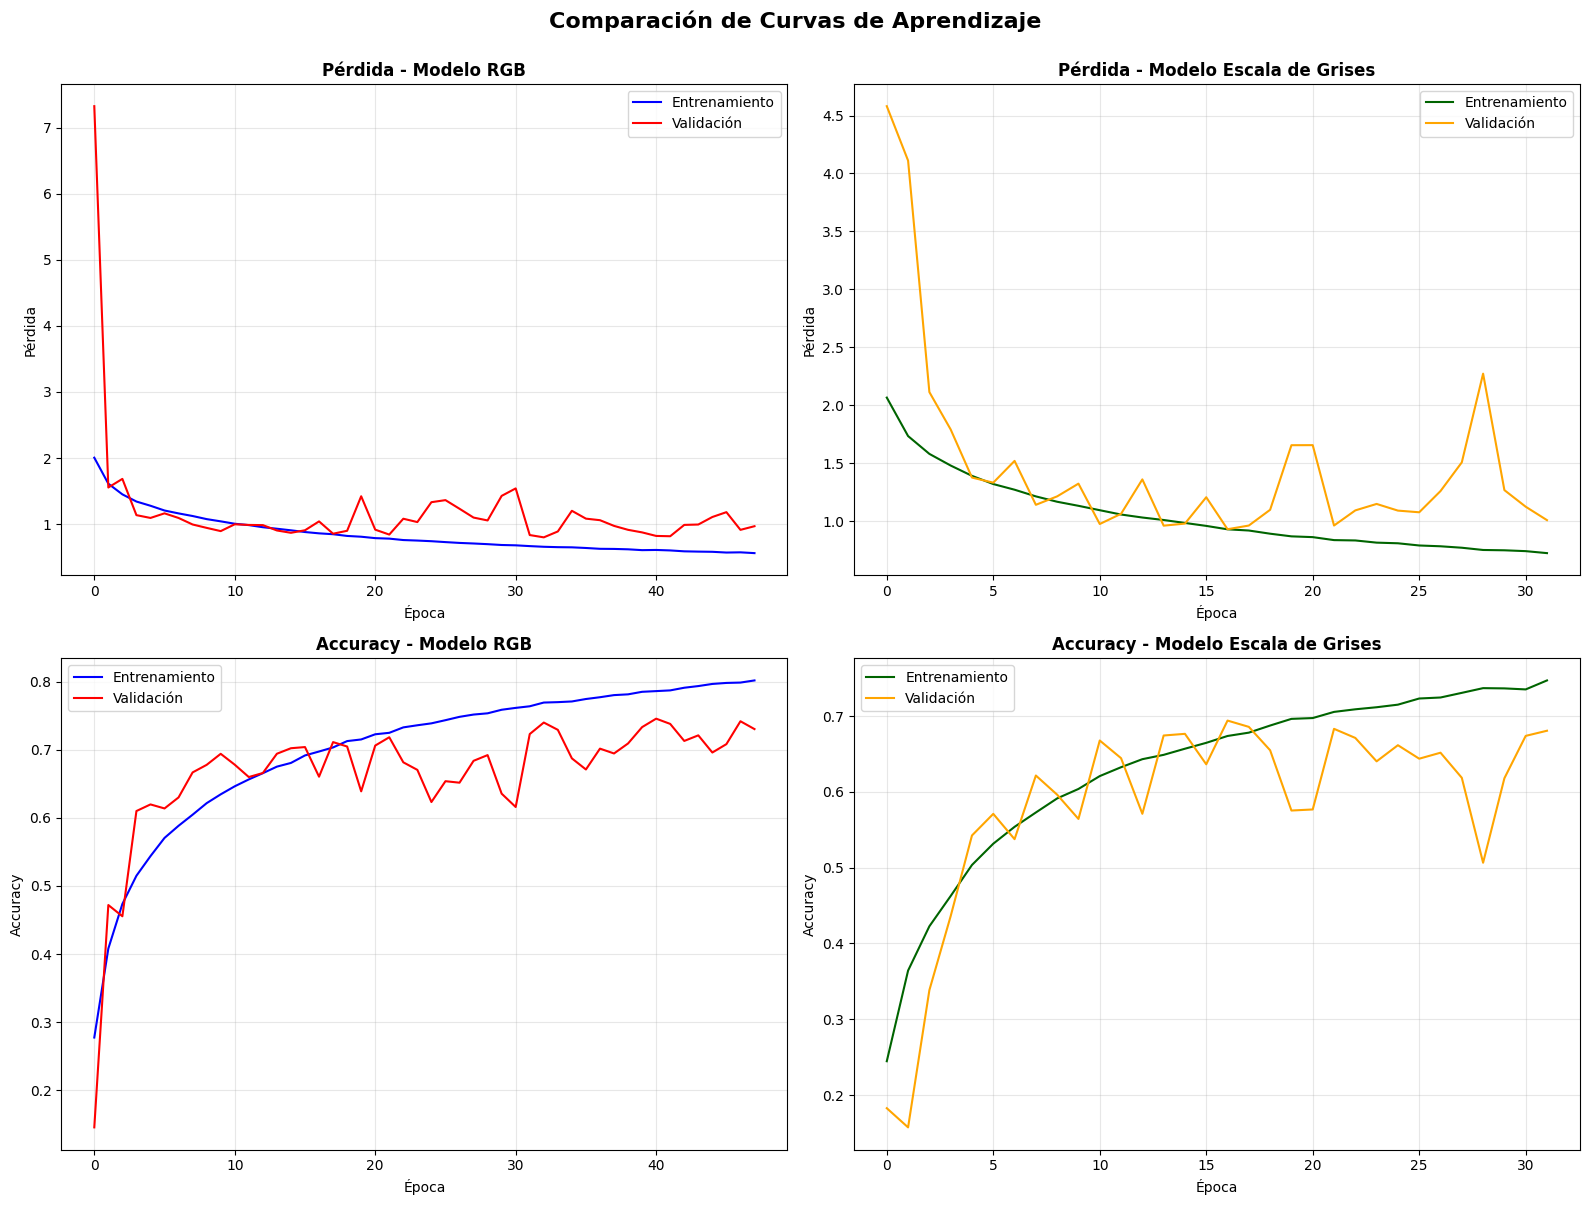

In [24]:
# Comparación de curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Pérdida - RGB
axes[0, 0].plot(history_rgb.history['loss'], label='Entrenamiento', color='blue')
axes[0, 0].plot(history_rgb.history['val_loss'], label='Validación', color='red')
axes[0, 0].set_title('Pérdida - Modelo RGB', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Pérdida')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Pérdida - Escala de Grises
axes[0, 1].plot(history_gray.history['loss'], label='Entrenamiento', color='darkgreen')
axes[0, 1].plot(history_gray.history['val_loss'], label='Validación', color='orange')
axes[0, 1].set_title('Pérdida - Modelo Escala de Grises', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Pérdida')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy - RGB
axes[1, 0].plot(history_rgb.history['accuracy'], label='Entrenamiento', color='blue')
axes[1, 0].plot(history_rgb.history['val_accuracy'], label='Validación', color='red')
axes[1, 0].set_title('Accuracy - Modelo RGB', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Accuracy - Escala de Grises
axes[1, 1].plot(history_gray.history['accuracy'], label='Entrenamiento', color='darkgreen')
axes[1, 1].plot(history_gray.history['val_accuracy'], label='Validación', color='orange')
axes[1, 1].set_title('Accuracy - Modelo Escala de Grises', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Comparación de Curvas de Aprendizaje', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

ANÁLISIS DE RENDIMIENTO POR CLASE - COMPARACIÓN

     Clase   F1 RGB  F1 Grises  Diferencia  Precision RGB  Precision Grises  Recall RGB  Recall Grises  Muestras
  Airplane 0.766434   0.717582    0.048851       0.717904          0.796341       0.822          0.653      1000
Automobile 0.844212   0.834331    0.009880       0.806187          0.832669       0.886          0.836      1000
      Bird 0.637205   0.552982    0.084223       0.655391          0.545190       0.620          0.561      1000
       Cat 0.508806   0.468767    0.040040       0.498084          0.502864       0.520          0.439      1000
      Deer 0.700701   0.649804    0.050897       0.701403          0.576179       0.700          0.745      1000
       Dog 0.612717   0.584896    0.027821       0.591078          0.629758       0.636          0.546      1000
      Frog 0.819346   0.745526    0.073820       0.779080          0.661503       0.864          0.854      1000
     Horse 0.780359   0.748954    0.031405     

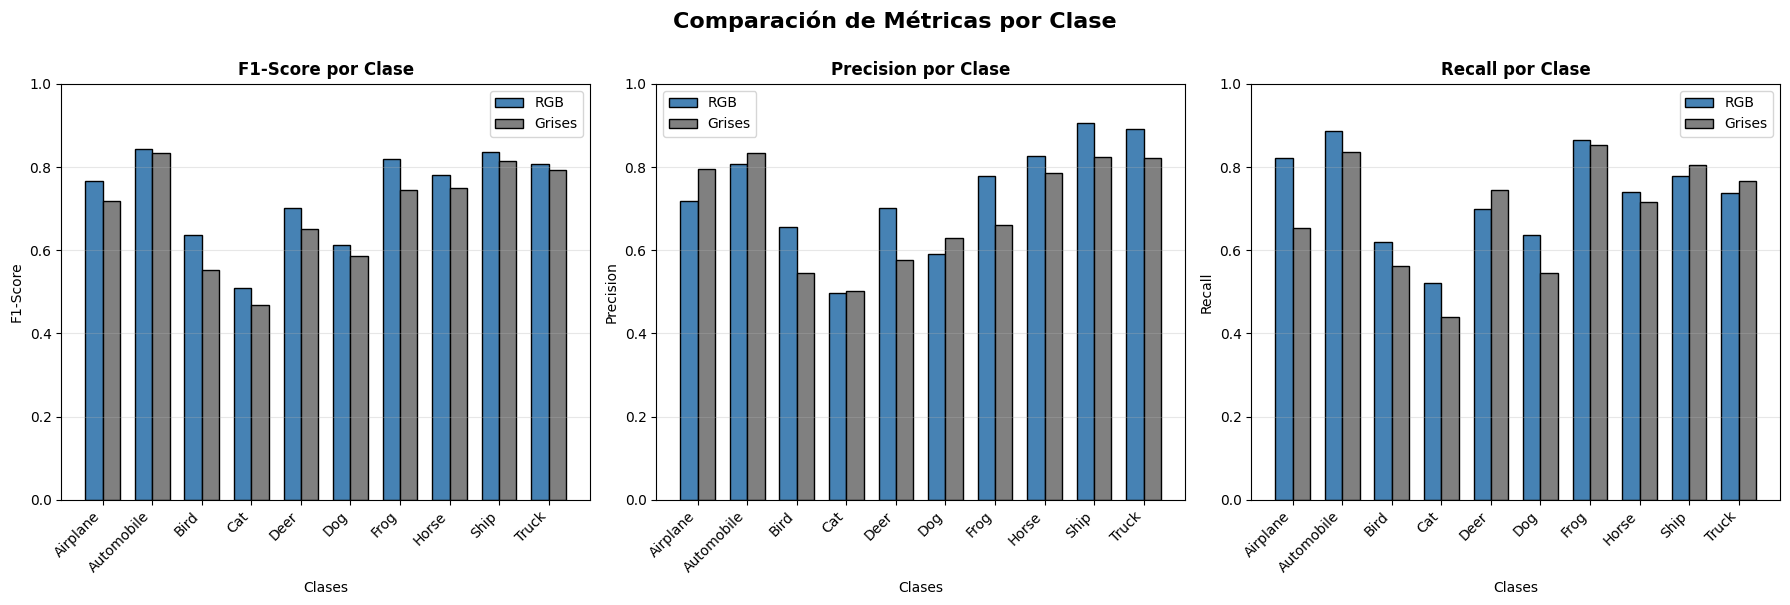


ANÁLISIS DE DIFERENCIAS POR CLASE

📈 Clases donde RGB es significativamente mejor (>2% F1-Score):
   • Airplane: RGB=0.766 vs Grises=0.718 (Δ=0.049)
   • Bird: RGB=0.637 vs Grises=0.553 (Δ=0.084)
   • Cat: RGB=0.509 vs Grises=0.469 (Δ=0.040)
   • Deer: RGB=0.701 vs Grises=0.650 (Δ=0.051)
   • Dog: RGB=0.613 vs Grises=0.585 (Δ=0.028)
   • Frog: RGB=0.819 vs Grises=0.746 (Δ=0.074)
   • Horse: RGB=0.780 vs Grises=0.749 (Δ=0.031)
   • Ship: RGB=0.837 vs Grises=0.815 (Δ=0.021)

⚖️ Clases con rendimiento similar (2 clases):
   • Automobile
   • Truck


In [25]:
# Análisis de rendimiento por clase para ambos modelos
from sklearn.metrics import precision_recall_fscore_support

print("="*80)
print("ANÁLISIS DE RENDIMIENTO POR CLASE - COMPARACIÓN")
print("="*80 + "\n")

# Calcular métricas por clase para ambos modelos
precision_rgb, recall_rgb, f1_rgb, _ = precision_recall_fscore_support(
    y_test, y_pred_classes_rgb, average=None, zero_division=0
)

precision_gray, recall_gray, f1_gray, support = precision_recall_fscore_support(
    y_test, y_pred_classes_gray, average=None, zero_division=0
)

# Crear DataFrame comparativo
df_comparacion_clases = pd.DataFrame({
    'Clase': class_names,
    'F1 RGB': f1_rgb,
    'F1 Grises': f1_gray,
    'Diferencia': f1_rgb - f1_gray,
    'Precision RGB': precision_rgb,
    'Precision Grises': precision_gray,
    'Recall RGB': recall_rgb,
    'Recall Grises': recall_gray,
    'Muestras': support
})

print(df_comparacion_clases.to_string(index=False))

# Visualización comparativa por clase
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# F1-Score por clase
x_pos = np.arange(len(class_names))
width = 0.35

axes[0].bar(x_pos - width/2, f1_rgb, width, label='RGB', color='steelblue', edgecolor='black')
axes[0].bar(x_pos + width/2, f1_gray, width, label='Grises', color='gray', edgecolor='black')
axes[0].set_xlabel('Clases')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score por Clase', fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Precision por clase
axes[1].bar(x_pos - width/2, precision_rgb, width, label='RGB', color='steelblue', edgecolor='black')
axes[1].bar(x_pos + width/2, precision_gray, width, label='Grises', color='gray', edgecolor='black')
axes[1].set_xlabel('Clases')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision por Clase', fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

# Recall por clase
axes[2].bar(x_pos - width/2, recall_rgb, width, label='RGB', color='steelblue', edgecolor='black')
axes[2].bar(x_pos + width/2, recall_gray, width, label='Grises', color='gray', edgecolor='black')
axes[2].set_xlabel('Clases')
axes[2].set_ylabel('Recall')
axes[2].set_title('Recall por Clase', fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim([0, 1])

plt.suptitle('Comparación de Métricas por Clase', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Identificar clases donde RGB es mejor y viceversa
print("\n" + "="*80)
print("ANÁLISIS DE DIFERENCIAS POR CLASE")
print("="*80)

mejora_rgb = df_comparacion_clases[df_comparacion_clases['Diferencia'] > 0.02]
mejora_gray = df_comparacion_clases[df_comparacion_clases['Diferencia'] < -0.02]

if len(mejora_rgb) > 0:
    print("\n📈 Clases donde RGB es significativamente mejor (>2% F1-Score):")
    for _, row in mejora_rgb.iterrows():
        print(f"   • {row['Clase']}: RGB={row['F1 RGB']:.3f} vs Grises={row['F1 Grises']:.3f} (Δ={row['Diferencia']:.3f})")

if len(mejora_gray) > 0:
    print("\n📈 Clases donde Escala de Grises es significativamente mejor (>2% F1-Score):")
    for _, row in mejora_gray.iterrows():
        print(f"   • {row['Clase']}: Grises={row['F1 Grises']:.3f} vs RGB={row['F1 RGB']:.3f} (Δ={abs(row['Diferencia']):.3f})")

similar = df_comparacion_clases[(df_comparacion_clases['Diferencia'] >= -0.02) &
                                 (df_comparacion_clases['Diferencia'] <= 0.02)]
if len(similar) > 0:
    print(f"\n⚖️ Clases con rendimiento similar ({len(similar)} clases):")
    for clase in similar['Clase'].values:
        print(f"   • {clase}")

print("="*80)

COMPARACIÓN VISUAL DE PREDICCIONES

Casos donde solo RGB acierta: 1226
Casos donde solo Escala de Grises acierta: 846
Casos donde ambos fallan: 1851
Casos donde ambos aciertan: 6077

CASOS DONDE SOLO RGB ACIERTA


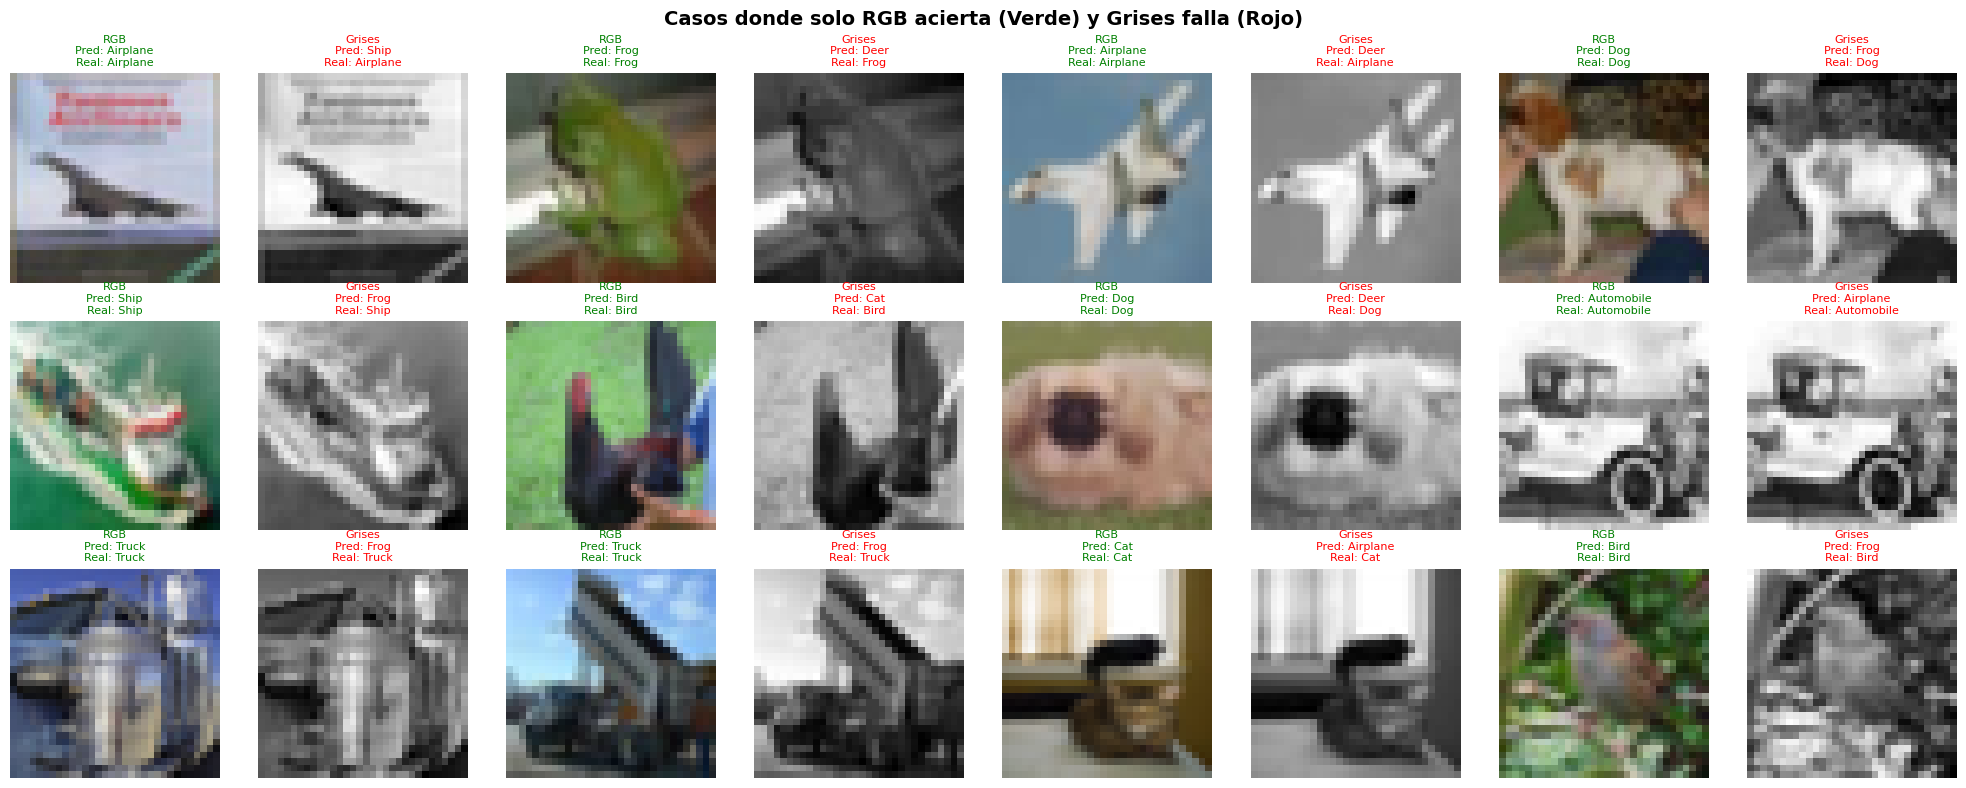


CASOS DONDE SOLO ESCALA DE GRISES ACIERTA


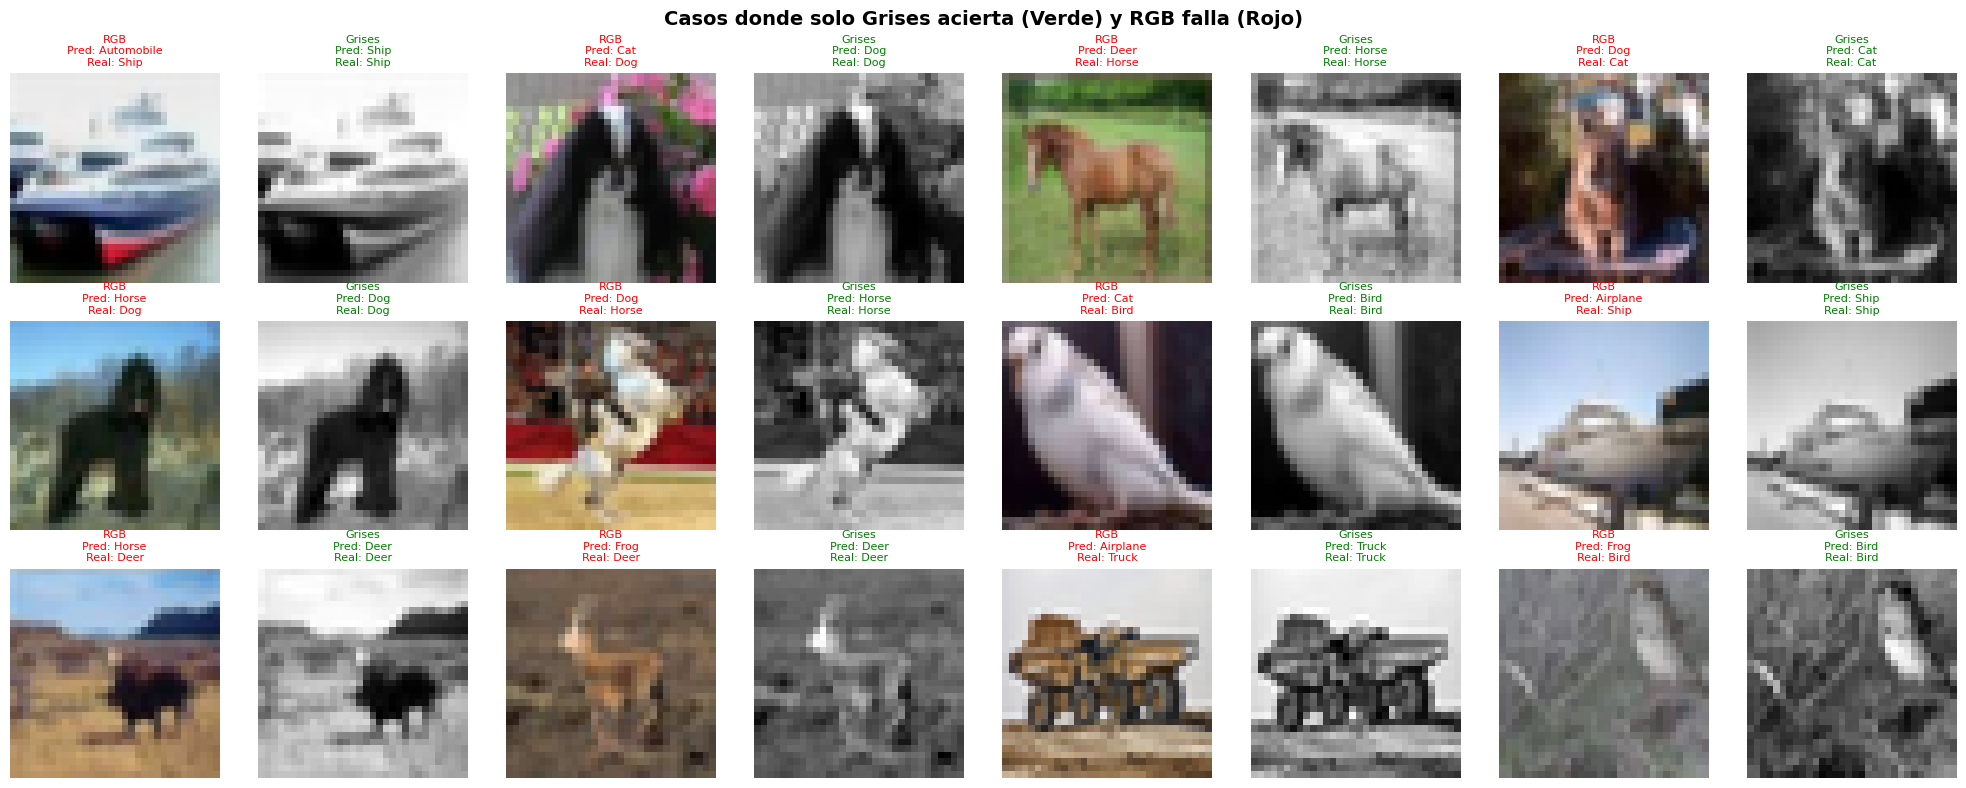


FIN DEL ANÁLISIS COMPARATIVO


In [26]:
# Comparación lado a lado de predicciones
print("="*80)
print("COMPARACIÓN VISUAL DE PREDICCIONES")
print("="*80 + "\n")

# Seleccionar casos interesantes: donde un modelo acierta y el otro no
rgb_correcto_gray_incorrecto = np.where((y_pred_classes_rgb == y_test) & (y_pred_classes_gray != y_test))[0]
gray_correcto_rgb_incorrecto = np.where((y_pred_classes_gray == y_test) & (y_pred_classes_rgb != y_test))[0]
ambos_incorrectos = np.where((y_pred_classes_rgb != y_test) & (y_pred_classes_gray != y_test))[0]

print(f"Casos donde solo RGB acierta: {len(rgb_correcto_gray_incorrecto)}")
print(f"Casos donde solo Escala de Grises acierta: {len(gray_correcto_rgb_incorrecto)}")
print(f"Casos donde ambos fallan: {len(ambos_incorrectos)}")
print(f"Casos donde ambos aciertan: {len(y_test) - len(rgb_correcto_gray_incorrecto) - len(gray_correcto_rgb_incorrecto) - len(ambos_incorrectos)}")

# Visualizar casos donde solo RGB acierta
if len(rgb_correcto_gray_incorrecto) > 0:
    print(f"\n{'='*80}")
    print("CASOS DONDE SOLO RGB ACIERTA")
    print(f"{'='*80}")

    num_mostrar = min(12, len(rgb_correcto_gray_incorrecto))
    indices_mostrar = rgb_correcto_gray_incorrecto[:num_mostrar]

    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]

        # RGB (izquierda)
        axes[i//4, (i%4)*2].imshow(X_test[idx])
        axes[i//4, (i%4)*2].set_title(f'RGB\nPred: {class_names[y_pred_classes_rgb[idx]]}\nReal: {class_names[y_test[idx]]}',
                                      fontsize=8, color='green')
        axes[i//4, (i%4)*2].axis('off')

        # Grises (derecha)
        axes[i//4, (i%4)*2+1].imshow(X_test_gray[idx], cmap='gray')
        axes[i//4, (i%4)*2+1].set_title(f'Grises\nPred: {class_names[y_pred_classes_gray[idx]]}\nReal: {class_names[y_test[idx]]}',
                                        fontsize=8, color='red')
        axes[i//4, (i%4)*2+1].axis('off')

    # Ocultar ejes sobrantes
    for i in range(num_mostrar, 12):
        axes[i//4, (i%4)*2].axis('off')
        axes[i//4, (i%4)*2+1].axis('off')

    plt.suptitle('Casos donde solo RGB acierta (Verde) y Grises falla (Rojo)',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Visualizar casos donde solo Grises acierta
if len(gray_correcto_rgb_incorrecto) > 0:
    print(f"\n{'='*80}")
    print("CASOS DONDE SOLO ESCALA DE GRISES ACIERTA")
    print(f"{'='*80}")

    num_mostrar = min(12, len(gray_correcto_rgb_incorrecto))
    indices_mostrar = gray_correcto_rgb_incorrecto[:num_mostrar]

    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    for i in range(num_mostrar):
        idx = indices_mostrar[i]

        # RGB (izquierda)
        axes[i//4, (i%4)*2].imshow(X_test[idx])
        axes[i//4, (i%4)*2].set_title(f'RGB\nPred: {class_names[y_pred_classes_rgb[idx]]}\nReal: {class_names[y_test[idx]]}',
                                      fontsize=8, color='red')
        axes[i//4, (i%4)*2].axis('off')

        # Grises (derecha)
        axes[i//4, (i%4)*2+1].imshow(X_test_gray[idx], cmap='gray')
        axes[i//4, (i%4)*2+1].set_title(f'Grises\nPred: {class_names[y_pred_classes_gray[idx]]}\nReal: {class_names[y_test[idx]]}',
                                        fontsize=8, color='green')
        axes[i//4, (i%4)*2+1].axis('off')

    # Ocultar ejes sobrantes
    for i in range(num_mostrar, 12):
        axes[i//4, (i%4)*2].axis('off')
        axes[i//4, (i%4)*2+1].axis('off')

    plt.suptitle('Casos donde solo Grises acierta (Verde) y RGB falla (Rojo)',
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("FIN DEL ANÁLISIS COMPARATIVO")
print("="*80)